# MPW2 - Computational graphs

In [1]:
import random
import pandas as pd
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
from cgnodes import *

In this notebook, spot the **TO_COMPLETE** comments in the code and in the markdown cells. Don't hesitate to add your own code and markdown cells to complete the exercises. You can also add comments in the code to explain your reasoning.

## 1. Simple computational graph framework

Let's do a simple test with the available computational graph framework. The function to compute is $f = (x_1 x_2)^2$

![Simple computational graph](../images/simple-graph-1.jpg)

In [2]:
# first create all ValueNode objects
x1 = ValueNode()
x2 = ValueNode()
q = ValueNode()
f = ValueNode()

# then create all <Operator>Node objects
mult = MultiplyNode(x1, x2, q)
square = SquareNode(q, f)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x1, x2], [f])

# test the graph with some random inputs
cg.forward([2.0, 4.0])
print(f"f = {f.v}")  # should print 64.0

f = 64.0


## 2. Get a dataset
### 2.1 Read data
We will use a simple dataset for this exercise with rent prices of appartments in Lausanne, as a function of the living area in square meters and the number of rooms. Define the path to the file containing the CSV data and read the data using Pandas.

In [3]:
datafile = "../data/lausanne-appart.csv"
dataset = pd.read_csv(datafile)
dataset.head()

,living_area,nb_rooms,rent_price
0,69,3.0,1810
1,95,3.5,2945
2,21,1.5,685
3,20,1.0,720
4,33,1.5,830


In [4]:
# get the data as numpy arrays for the rent price and the living area
rent_price = dataset.rent_price.values
living_area = dataset.living_area.values

### 2.2 Visualize the data
Plot a scatter plot of renting price as a function of living area

In [5]:
# in this function, x_curve and y_curve are the points of the model curve to plot (what the model estimates),
# they are optional. Theta_0, theta_1, theta_2 are the parameters of the model to display in the legend, 
# also optional.
def plot_data_prediction(
        x_points,
        y_points,
        x_curve=None,
        y_curve=None,
        x_title='x',
        y_title='y',
        theta_0=None,
        theta_1=None,
        theta_2=None):
    plt.title("{} as a function of {}".format(y_title, x_title))
    plt.xlabel(x_title)   # ex "Living area (m^2)"
    plt.ylabel(y_title)   # ex "Rent (CHF)"
    plt.scatter(x_points, y_points, label="data")
    model_label = "model"
    if theta_0 is not None and theta_1 is not None:
        model_label = fr"model ($\theta_0={theta_0:.3f}$, $\theta_1={theta_1:.3f}$)"
    if theta_0 is not None and theta_1 is not None and theta_2 is not None:
        model_label += fr", $\theta_2={theta_2:.3f}$)"
    if x_curve is not None and y_curve is not None:
        plt.plot(x_curve, y_curve, color="red", label=model_label)
    plt.legend()
    plt.grid(True)
    plt.show()

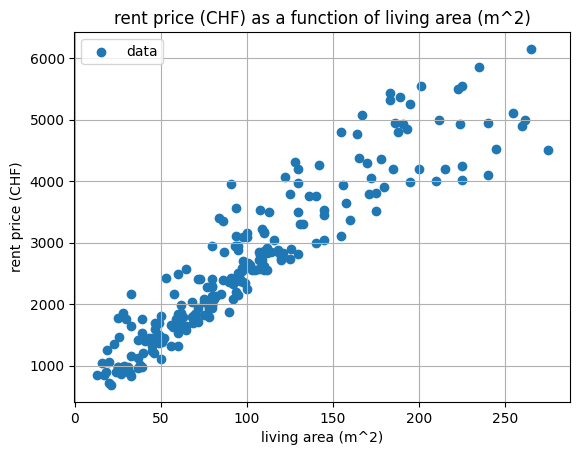

In [6]:
plot_data_prediction(living_area, rent_price, x_title='living area (m^2)', y_title='rent price (CHF)')

## 3. Normal equations for linear regression

The simplest regression model is a linear model defined with the parameters $\theta$ as follows:

\begin{equation*}
	\hat{y} = h_{\theta}(\mathbf{x}) = \theta_{0} + \theta_{1} x
\end{equation*}

We can find the optimal parameters $\theta$ for linear regression by minimizing the mean squared error (MSE) between the predicted values and the actual values. The MSE loss is given by:

\begin{equation*}
	J(\theta) = \frac{1}{2N} \sum_{n=1}^{N} (\hat{y}_{n} - y_{n})^{2}
\end{equation*}

This is a classical optimization problem that can be solved using calculus. The closed form solution to this problem is the following :

\begin{equation*}
	\theta = (X^{T}X)^{-1}X^{T}\vec{y}
\end{equation*}

intercept (theta_0): 657.6890591150313
slope (theta_1)    : 19.661179947454315


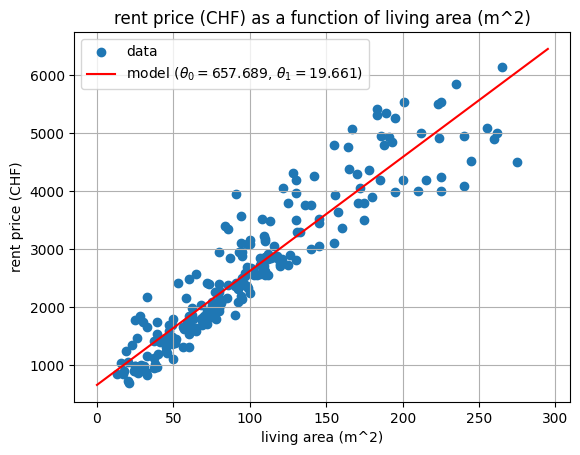

In [7]:
# see Eq. (3), (4) and (5) of the MPW2 pdf
X = np.c_[np.ones(len(living_area)), living_area]
y = rent_price
theta = inv(X.T @ X) @ X.T @ y

print("intercept (theta_0):", theta[0])  # should be around 658
print("slope (theta_1)    :", theta[1])  # should be around 19.7

x_curve = np.array(np.linspace(0, np.max(X) + 20, 200))
y_curve = theta[0] + theta[1] * x_curve

plot_data_prediction(
    living_area,
    rent_price,
    x_curve,
    y_curve,
    x_title='living area (m^2)',
    y_title='rent price (CHF)',
    theta_0=theta[0],
    theta_1=theta[1],
)

The values of $\theta_0$ and $\theta_1$ obtained above are your references for the rest of the exercises.
Parameter $\theta_1$ defines the slope, equal to the augmentation of the rent price for each additional square meter of living area. Parameter $\theta_0$ defines the intercept, equal to the rent price when the living area is zero. We can observe a price evolution of around 20 CHF per additional square meter ($\theta_1 = 19.7$).

b) Compute the overall MSE loss :

In [8]:
def mse_loss(y_hat, y):
    sq_error = (y_hat - y) ** 2
    return np.mean(sq_error) / 2

y_hat = theta[0] + theta[1] * living_area
J = mse_loss(y_hat, y)
print("The total value of the loss is", J)  # should be around 105K

The total value of the loss is 104915.13056913581


This value is minimum with the optimal $\theta$. It is pretty large because the data is noisy and the model is very simple (linear regression). Another frequently used metric is the root mean squared error (RMSE) which is the square root of the MSE. It is in the same unit as the target variable and is easier to interpret. Other commonly used metrics are the mean absolute error (MAE) and the mean absolute percentage error (MAPE). MAE is the average of the absolute  differences between the predicted values and the actual values. It is also in the same unit as the target variable and is less sensitive to outliers than the MSE. MAPE is the average of the absolute percentage differences between the predicted values and the actual values. It is a relative error metric that is useful when the target variable has a wide range of values.

In [9]:
def rmse_loss(y_hat, y):
    sq_error = (y_hat - y) ** 2
    return np.sqrt(np.mean(sq_error))

def mae_loss(y_hat, y):
    abs_error = np.abs(y_hat - y)
    return np.mean(abs_error)

def mape_loss(y_hat, y):
    abs_pct_error = np.abs((y_hat - y) / y)
    return np.mean(abs_pct_error)

rmse = rmse_loss(y_hat, y)
mae = mae_loss(y_hat, y)
mape = mape_loss(y_hat, y)
mape_percent = 100 * mape
print("The total value of the RMSE loss is", round(rmse))
print("The total value of the MAE loss is", round(mae))
print("The total value of the MAPE loss is", f"{mape_percent:.1f}%")

The total value of the RMSE loss is 458
The total value of the MAE loss is 347
The total value of the MAPE loss is 14.6%


TO COMPLETE : Implement the functions above to compute the MSE, RMSE, MAE and MAPE losses. Compute these losses for the linear regression model with the optimal $\theta$ obtained above. Interpret the results.
Extra question: What could be the problem with MAPE ?

MAPE is problematic because it divides by the true value $( y_i )$.

* If $( y_i = 0 )$, MAPE is **undefined** (division by zero).
* If $( y_i )$ is very small, MAPE becomes **extremely large and unstable**.
* It can **bias evaluation**, often penalizing overestimation differently than underestimation.

## 4. Stochastic gradient descent for linear regression with computational graph

### 4.1 Graph creation

We need now to create a computational graph for the linear regression model and the MSE loss. The graph should have the following structure:

![Linear regression computational graph](../images/linear-regression-graph.jpg)

Before creating the graph, you need to complete the Python code __cgnodes.py__ with a new operator node __MSELossNode(MetaNode)__ that computes the MSE loss between the predicted values and the actual values. The node should have two inputs: the predicted values and the actual values. The node should have one output: the MSE loss.

Then you can create the graph below.

In [10]:
### TO COMPLETE  - CREATE THE GRAPH ###
# first create all ValueNode objects

# Input
x = ValueNode()
theta_0 = ValueNode()
theta_1 = ValueNode()
y = ValueNode()

#intermediate
q = ValueNode()
y_hat = ValueNode()

# output
j = ValueNode()


# then create all <Operator>Node objects
multi_x_theta1 = MultiplyNode(x, theta_1, q)
add_q_theta0 = AddNode([q, theta_0], y_hat)
mse_loss_node = MSELossNode(y_hat, y, j)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x, theta_0, theta_1, y], [j])

In [11]:
# try a forward pass with dummy values
cg.reset_values()
cg.forward([0.0, 0.0, 0.0, 1.0])
print(j.v)  # should give 0.5

0.5


In [12]:
cg.backward()
print(theta_0.grad_v, theta_1.grad_v)  # should give -1.0 -0.0

-1.0 -0.0


### 4.2 Plain vanilla stochastic gradient descent

In [13]:
# this function plots the evolution of the loss and the parameters during training, as well
# as the data points and the model curve at the end of training. The last value of the 
# evolution of theta_0 and theta_1 is used to plot the model curve.
def plot_training_log(loss_evolution, t0_evolution, t1_evolution, x, y):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,7))
    fig.suptitle('Training log')
    ax1.plot(t0_evolution)
    ax1.set_title('theta 0')
    ax2.plot(t1_evolution)
    ax2.set_title('theta 1')
    ax3.plot(loss_evolution)
    ax3.set_title('loss')
    ax4.scatter(x, y, s=1.0)
    x_curve = np.array(np.linspace(np.min(x), np.max(x), 2))
    y_curve = t0_evolution[-1] + t1_evolution[-1] * x_curve  # use last value of evolution as thetas
    ax4.plot(x_curve, y_curve, color='red')
    ax4.set_title('points and model output')
    fig.tight_layout()

Complete the code below to implement the stochastic gradient descent algorithm for linear regression. Make sure you understand the code and the algorithm before completing it. We will bring incremental evolution to this code so make sure you understand each lines of it. The code is pretty straightforward, but you can ask for help if you have any questions.

intercept (theta_0): 1.0018254596028748
slope (theta_1)    : 24.27049008024125
The total value of the loss is 163842.39214801902


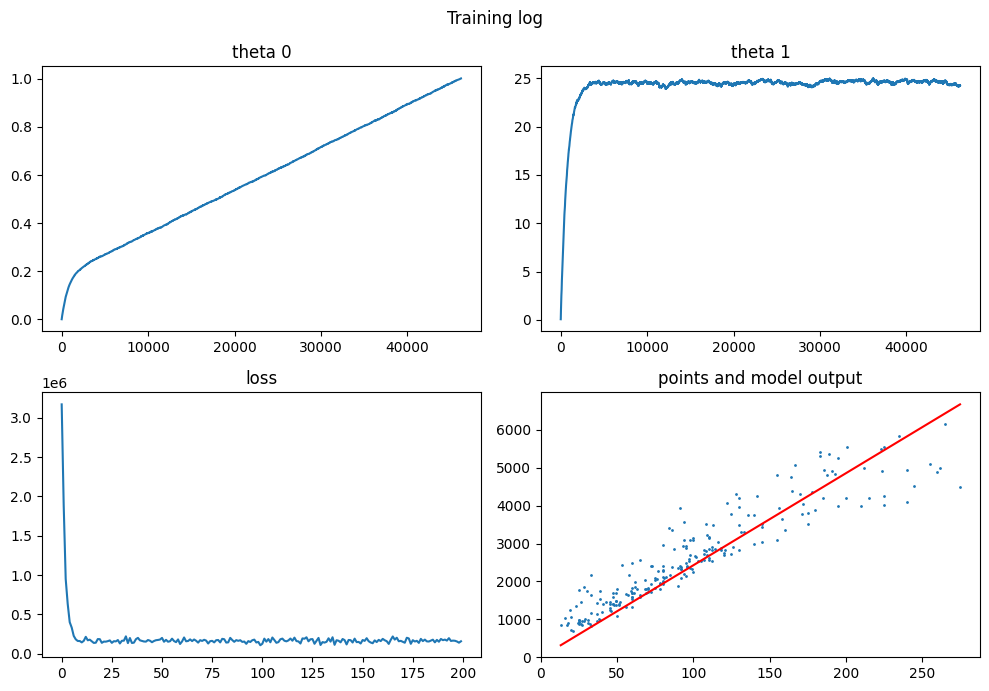

In [14]:
alpha = 0.0000001     # learning rate
epochs = 200          # number of epochs (an epoch is a loop over the whole training set)
N = len(living_area)  # number of samples in the training set
t0 = 0.0              # initial value of theta_0
t1 = 0.0              # initial value of theta_1

loss_evolution = []  # to log the evolution of the loss
t0_evolution = []    # to log the evolution of theta_0
t1_evolution = []    # to log the evolution of theta_1

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))  # random sampling in the training set
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        t0 = t0 - alpha * theta_0.grad_v   # update rule for theta_0
        t1 = t1 - alpha * theta_1.grad_v   # update rule for theta_1
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations** TO COMPLETE

* **Evolution of the loss:** The loss decreases very quickly at the beginning, showing that the model learns fast, then it stabilizes and slightly oscillates around a low value due to the stochastic nature of the updates. This indicates convergence.

* **Evolution of $( \theta_1 )$:** The parameter $( \theta_1 )$ increases rapidly from 0 to around 25, then reaches a plateau with small fluctuations. This shows that the model quickly finds the correct slope and then fine-tunes it.

* **Evolution of $( \theta_0 )$:** The parameter $( \theta_0 )$ increases more gradually and smoothly from 0 to about 1, with almost no oscillations. This indicates a slower and more stable adjustment.



### 4.3 Batched gradient descent

Modify the code from the above stochastic gradient descent to implement a batched gradient descent algorithm. The idea is to compute the gradients on a batch of samples instead of a single sample. This can help to smooth the evolution of the parameters and the loss, and can also speed up the convergence.

intercept (theta_0): 0.4629727759651961
slope (theta_1)    : 24.644406661673806
The total value of the loss is 163626.21119326763


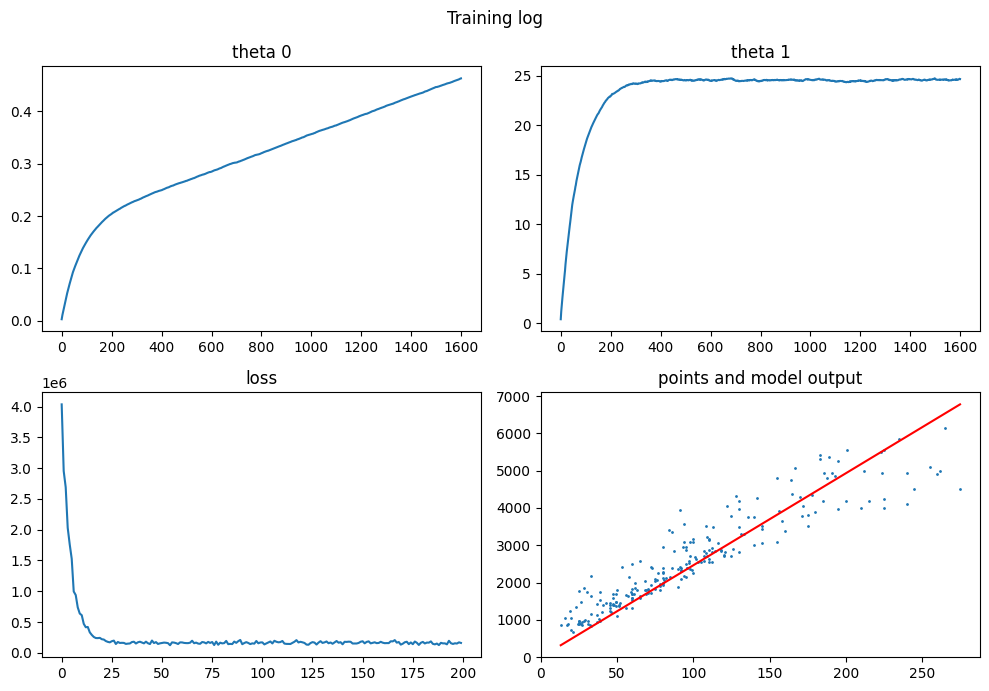

In [15]:
alpha = 0.000001  # learning rate can be higher than in the plain vanilla SGD 
                  # as we will average the gradients over a batch of samples
epochs = 200
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for step in range(n_steps):
        batch_indices = random.sample(range(0, N), min(batch_size, N))
        grad_t0 = 0.0
        grad_t1 = 0.0
        batch_loss = 0.0

        for n in batch_indices:
            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()
            grad_t0 += theta_0.grad_v
            grad_t1 += theta_1.grad_v
            batch_loss += j.v

        grad_t0 /= len(batch_indices)
        grad_t1 /= len(batch_indices)
        t0 = t0 - alpha * grad_t0
        t1 = t1 - alpha * grad_t1
        epoch_loss += batch_loss / len(batch_indices)
        t0_evolution.append(t0)
        t1_evolution.append(t1)
        # compute the gradients and update theta_0 and theta_1 with the average 
        # of the gradients over the batch

    loss_evolution.append(epoch_loss / n_steps)
    epoch_loss = 0.0

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations** TO COMPLETE

* **Evolution of theta_0 and theta_1:** With batch gradient descent, $( \theta_1 )$ quickly increases and converges around 24.5, while $( \theta_0 )$ increases much more slowly and smoothly. The parameter curves are less noisy than in the stochastic version.

* **Comparison with the plain stochastic version:** Yes, we still observe the same behavior: $( \theta_1 )$ converges quickly, while $( \theta_0 )$ evolves slowly. However, in batch gradient descent the convergence is smoother because the gradients are computed using the whole dataset instead of one random sample.

* **Learning rate:** Yes, we can usually use a larger learning rate than in the plain stochastic version, because batch gradient descent gives more stable gradient estimates. The updates are less noisy, so the training is more stable.


## 5. Optimizers
### 5.1 Idea 1: use different learning rates for $\theta_0$ and $\theta_1$

This is a very simple idea that can help to speed up the convergence of $\theta_0$ and $\theta_1$. We can use a larger learning rate for $\theta_1$ than for $\theta_0$ as $\theta_1$ converges faster than $\theta_0$. This idea is actually a first step towards RMSProp which is an optimizer that uses different learning rates for different parameters based on the history of the gradients.

intercept (theta_0): 20.645182313739642
slope (theta_1)    : 24.622767288835323
The total value of the loss is 160396.84383864334


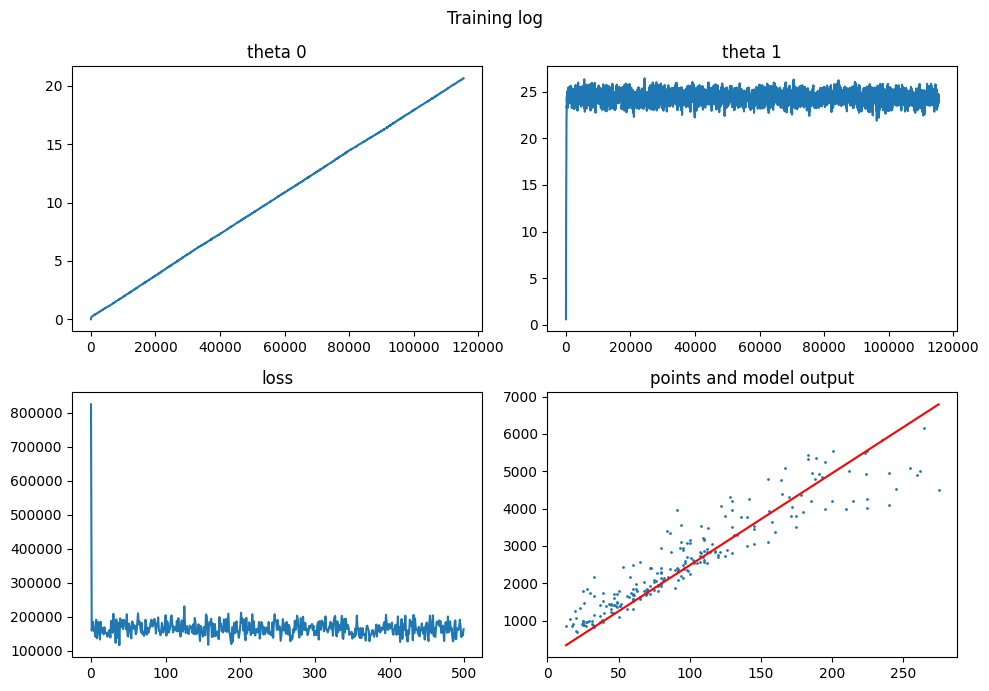

In [16]:
alpha_t0 = 0.00025    # learning rate for theta_0
alpha_t1 = 0.0000001  # learning rate for theta_1
epochs = 500          # number of epochs (an epoch is a loop over the whole training set)

N = len(living_area)  # number of samples in the training set
t0 = 0.0              # initial value of theta_0
t1 = 0.0              # initial value of theta_1

loss_evolution = []  # to log the evolution of the loss
t0_evolution = []    # to log the evolution of theta_0
t1_evolution = []    # to log the evolution of theta_1

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))  # random sampling in the training set
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        t0 = t0 - alpha * theta_0.grad_v   # update rule for theta_0
        t1 = t1 - alpha * theta_1.grad_v   # update rule for theta_1
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)
    

**Your observations**. TO COMPLETE

- θ₀: Converges much faster and further than in plain SGD (reaching ~20.5+ vs ~1 after 500 epochs). Still some oscillation due to the stochastic nature, but the larger learning rate finally makes it competitive with θ₁'s convergence speed
- θ₁: Behaves similarly to plain SGD — quick rise to plateau, but more noisy because θ₀ is now moving faster and perturbing the shared residual
- Loss: Decreases faster overall compared to plain SGD, because the bottleneck was θ₀'s slow progress. It should get closer to the normal equations reference loss (~105K).
- Plain SGD with a single learning rate forces a compromise — too large overshoots θ₁, too small starves θ₀. Per-parameter rates let each parameter move at the speed appropriate for its gradient scale. This is the core motivation behind adaptive optimizers like RMSProp, which computes these effective per-parameter rates from gradient history.


### 5.2 Idea 2: accelerate the movement of the parameters with the principle of momentum

The idea is to accelerate the modification of the parameters introducing a memory about the previous evolutions of the gradients. If the gradients are always in the same direction, we can accelerate the movement of the parameter updates in that direction. This is done by introducing a new variable called *momentum* that accumulates the gradients over time, and using this variable to update the parameters instead of the current gradient. The analogy would be to think of a ball rolling down the hill of parameter space, accelerating when the successive values of the gradients are aligned. The classical momentum equations are the following:

\begin{equation*}
	m^{(t+1)} = \beta \cdot m^{(t)} + \alpha \cdot grad^{(t)}
\end{equation*}

\begin{equation*}
    \theta^{(t+1)} = \theta^{(t)} - m^{(t+1)}
\end{equation*}

The value $\beta$ is multiplying the previous momentum and controls how much inertia we inject in the system. Values of $\beta$ above $1.0$ will make the system diverge and overflow. Too small $\beta$ value will not help if the way to the optimal value of the $\theta$ is far. A frequently used default is $\beta = 0.9$, but this is a value that needs to be tuned for each specific problem.

In our previous experiments, the parameter $\theta_0$ has gradients that seem to go always in the same direction. Convergence would benefit from this memory, accelerating the growth of $\theta_0$. This is less the case for $\theta_1$ which shows a quick convergence to a plateau, with gradients that are not always in the same direction. This is why we can expect a bigger improvement for $\theta_0$ than for $\theta_1$ with this idea. To handle this, we recommend to introduce two new variables `momentum_t0` and `momentum_t1` that accumulate the gradients of $\theta_0$ and $\theta_1$ respectively. We then use these momentum variables to update the parameters instead of the current gradients.

Complete the code below to implement the momentum optimizer for linear regression.

intercept (theta_0): 659.2906467374885
slope (theta_1)    : 19.88281395778791
The total value of the loss is 105278.41613709954


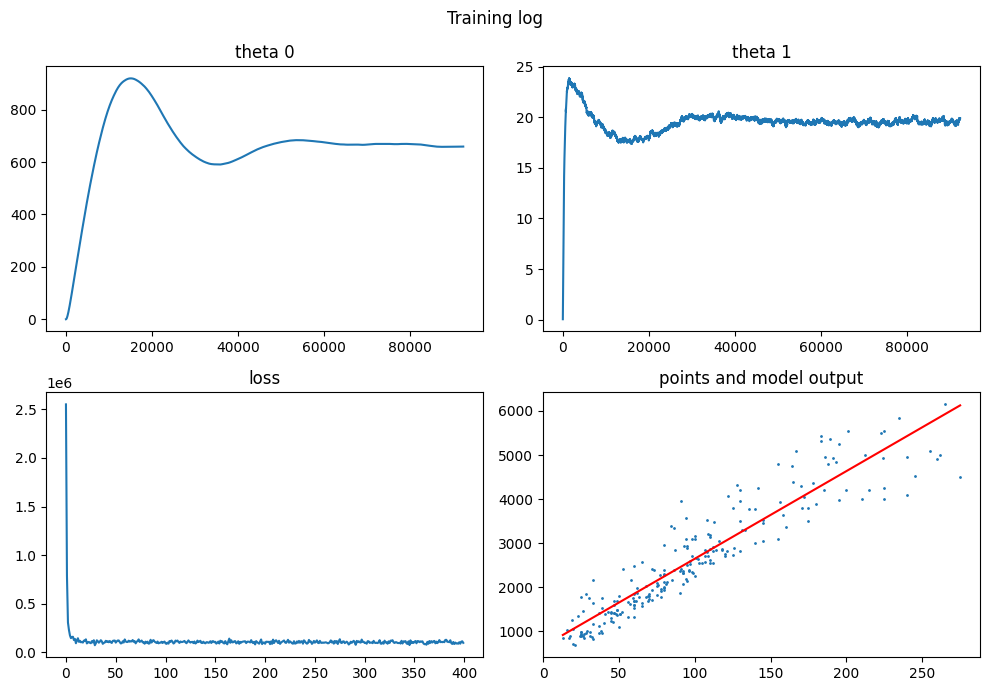

In [18]:
alpha = 0.0000001     # learning rate
beta_momentum_t0 = 0.9999     # momentum factor for theta_0
beta_momentum_t1 = 0.5000     # momentum factor for theta_1
momentum_t0 = 0.0
momentum_t1 = 0.0
epochs = 400          # number of epochs (an epoch is a loop over the whole training set)

N = len(living_area)  # number of samples in the training set
t0 = 0.0              # initial value of theta_0
t1 = 0.0              # initial value of theta_1

loss_evolution = []  # to log the evolution of the loss
t0_evolution = []    # to log the evolution of theta_0
t1_evolution = []    # to log the evolution of theta_1

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))  # random sampling in the training set
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        momentum_t0 = beta_momentum_t0 * momentum_t0 + alpha * theta_0.grad_v
        t0 = t0 - momentum_t0
        momentum_t1 = beta_momentum_t1 * momentum_t1 + alpha * theta_1.grad_v
        t1 = t1 - momentum_t1        
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)


**observations**

- θ₀ overshoots then plateaus at around 658, which is close to the closed-form solution. β = 0.9999 gives very high inertia — the momentum keeps accumulating in the "push up" direction and carries θ₀ past the optimum. Then the gradient flips sign (now the model overshoots predictions), momentum slowly reverses, and it settles.

- θ₁ is noisy and overshoots before settling close to the closed-form solution of around 19.7. β = 0.5 gives low inertia — only half the previous momentum is carried forward. θ₁'s gradients flip sign frequently (due to stochastic sampling), so a high β would amplify noise rather than help. Even with β = 0.5, the accumulated momentum is enough to cause some overshoot before the oscillating gradients wash out the memory.

- Despite the oscillations, momentum got both parameters to the correct optimum — something plain SGD failed to do for θ₀ in the same number of epochs. The different β values per parameter reflect that θ₀ benefits from long memory (consistent gradients) while θ₁ needs short memory (noisy gradients).

## Optional objectives

Pick at least 2 of the following optional objectives to further explore and analyze the performance of your models:

- **Investigate the use of 2nd order model instead of the simple linear model.**
- Re-implement and experiment with more advanced optimizers such as RMSProp, Nesterov or Adam.
- Implement an early stopping strategy in your training loop.
- Implement a \textit{Learning Rate Decay on Plateau} strategy in the training loop.
- **Normalize the input data with a zero norm approach and compare to your experiments without normalization.**


## Zero Norm Approach

- This optimization allows far higher learning rates without exploding gradients
- Smaller loss compared to non-normalized Regression
- Theta_0 stays very close to 0, which is expected as all values are centered around 0
- Theta_1 converges fast to around 0.95, which indicates strong positive correlation

In [ ]:
rent_price = dataset.rent_price.values
living_area = dataset.living_area.values

In [ ]:
def normalize_data(df):
    return (df- df.mean())/(df.std())

In [ ]:
rent_normalized = normalize_data(rent_price)
living_area_normalized = normalize_data(living_area)


In [ ]:
alpha = 0.01
epochs = 200
N = len(living_area_normalized)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area_normalized[n], t0, t1, rent_normalized[n]])
        cg.backward()
        t0 = t0 - alpha * theta_0.grad_v
        t1 = t1 - alpha * theta_1.grad_v
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area_normalized
J = mse_loss(y_hat, rent_normalized)

# Convert loss to squared Swiss Francs (CHF^2)
rent_variance = rent_price.std() ** 2
J_chf2 = J * rent_variance
lowest_loss_chf2 = np.min(loss_evolution) * rent_variance
loss_evolution_chf2 = [loss * rent_variance for loss in loss_evolution]

print("The total value of the loss (normalized) is", J)
print(f"The total value of the loss is: {J_chf2:.2f}")
print(f"The lowest loss (CHF^2) is: {lowest_loss_chf2:.2f}")

# Plot using the CHF^2 loss evolution
plot_training_log(loss_evolution_chf2, t0_evolution, t1_evolution, living_area_normalized, rent_normalized)

In [ ]:
# Calculate the variance of the original rent prices
rent_variance = dataset['rent_price'].std() ** 2

# Convert the normalized losses back to CHF^2
linear_loss_chf2 = 0.065393 * rent_variance
second_order_loss_chf2 = 0.062016 * rent_variance

print(f"Linear Model Loss (CHF^2): {linear_loss_chf2:.2f}")
print(f"Second Order Model Loss (CHF^2): {second_order_loss_chf2:.2f}")

## Second Order Model
- Higher capacity of model so that some non-linearity can be captured
- Normalization makes second order model very more stable
- Slightly improved loss over zero-norm approach indicates slight non-linearity
### New Method for Plotting

In [ ]:
def plot_training_log_2nd_order(loss_evolution, t0_ev, t1_ev, t2_ev, x, y):
    import matplotlib.pyplot as plt
    import numpy as np

    fig, axes = plt.subplots(3, 2, figsize=(12, 10))
    fig.suptitle('Training log (2nd Order Model)', fontsize=16)

    axes[0, 0].plot(t0_ev)
    axes[0, 0].set_title('theta 0')

    axes[0, 1].plot(t1_ev)
    axes[0, 1].set_title('theta 1')

    axes[1, 0].plot(t2_ev)
    axes[1, 0].set_title('theta 2')

    axes[1, 1].plot(loss_evolution)
    axes[1, 1].set_title('loss')

    axes[2, 0].scatter(x, y, s=5.0, alpha=0.7, label='data')
    sort_idx = np.argsort(x)
    x_sorted = x[sort_idx]

    y_curve = t0_ev[-1] + t1_ev[-1] * x_sorted + t2_ev[-1] * (x_sorted**2)
    axes[2, 0].plot(x_sorted, y_curve, color='red', linewidth=2, label='model (2nd order)')
    axes[2, 0].set_title('points and model output')
    axes[2, 0].legend()

    axes[2, 1].axis('off')
    fig.tight_layout()
    plt.show()

### Creation of new Comptuational Graph

In [ ]:
# first create all ValueNode objects
x = ValueNode()
x_squared = ValueNode()
theta_0 = ValueNode()
theta_1 = ValueNode()
theta_2 = ValueNode()
q_1 = ValueNode()
q_2 = ValueNode()
y_hat = ValueNode()
y = ValueNode()
j = ValueNode()

# then create all <Operator>Node objects
mult = MultiplyNode(x, theta_1, q_1)

square = SquareNode(x, x_squared)
mult_x_squared = MultiplyNode(x_squared, theta_2,q_2)

addition = AddNode([theta_0, q_1, q_2], y_hat)
mse_loss_node = MSELossNode(y_hat, y, j)


# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg_second_order = CompGraph([x, theta_0, theta_1,theta_2, y], [j])


### Linear Regression

In [ ]:
alpha = 0.01
epochs = 200
N = len(living_area_normalized)
t0 = 0.0
t1 = 0.0
t2 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []
t2_evolution = []

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))
        cg_second_order.reset_values()
        cg_second_order.forward([living_area_normalized[n], t0, t1,t2, rent_normalized[n]])
        cg_second_order.backward()
        t0 = t0 - alpha * theta_0.grad_v
        t1 = t1 - alpha * theta_1.grad_v
        t2 = t2 - alpha * theta_2.grad_v
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
        t2_evolution.append(t2)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
print("curvature (theta_2):", t2)
y_hat = t0 + t1 * living_area_normalized + t2 * (living_area_normalized**2)
J = mse_loss(y_hat, rent_normalized)

# Convert loss to squared Swiss Francs (CHF^2)
rent_variance = rent_price.std() ** 2
J_chf2 = J * rent_variance
lowest_loss_chf2 = np.min(loss_evolution) * rent_variance
loss_evolution_chf2 = [loss * rent_variance for loss in loss_evolution]

print("The total value of the loss (normalized) is", J)
print(f"The total value of the loss (CHF^2) is: {J_chf2:.2f}")
print(f"The lowest loss (CHF^2) is: {lowest_loss_chf2:.2f}")

# Plot using the CHF^2 loss evolution
plot_training_log_2nd_order(loss_evolution_chf2, t0_evolution,t1_evolution,t2_evolution, living_area_normalized, rent_normalized)